In [1]:
import sys 
import os

In [2]:
current_dir = os.path.dirname(os.path.abspath('.'))
project_root = os.path.abspath(os.path.join(current_dir, ".."))
sys.path.insert(0, project_root)

In [3]:
import pandas as pd
import yaml
import pickle
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay
import shap

In [4]:
yaml_path = rf"..\config\config.yaml"
with open(yaml_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

In [5]:
yaml_path = rf"..\config\model.yaml"
with open(yaml_path, "r", encoding="utf-8") as f:
    config_model = yaml.safe_load(f)

# Params

# Read Train / val dataset

In [6]:
pipeline_name="Pipeline3"

In [7]:
X_train = pd.read_parquet(fr'..\data\feature_eng\X_train_feat_eng_{pipeline_name}.parquet')
y_train = pd.read_parquet(fr'..\data\feature_eng\y_train_feat_eng_{pipeline_name}.parquet')  

X_val = pd.read_parquet(fr'..\data\feature_eng\X_val_feat_eng_{pipeline_name}.parquet')
y_val = pd.read_parquet(fr'..\data\feature_eng\y_val_feat_eng_{pipeline_name}.parquet')

In [8]:
model = "RandomForestClassifier_Pipeline3"

In [9]:
model_path = rf'..\models\single_model\pkl\{model}.pkl'
with open(model_path, "rb") as file:
        model = pickle.load(file)

c:\Users\gustavo\anaconda3\envs\explain\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.5.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\gustavo\anaconda3\envs\explain\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.5.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\gustavo\anaconda3\envs\explain\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.

# Drop columns

In [10]:
X_train.drop(
    columns=config_model['single_model']['cols_2_drop'], 
    inplace=True)

X_val.drop(
    columns=config_model['single_model']['cols_2_drop'], 
    inplace=True)


In [11]:
X_train

,numerical_pipe_con__Age,numerical_pipe_con__Fare,numerical_pipe_dis__IsAlone,numerical_pipe_dis__FamilySize,categorical_pipe__Pclass,categorical_pipe__Title,categorical_pipe__Cabin_1p
331,0.198110,0.376343,0.812203,-0.243975,1.614136,-0.791063,1.303385
733,0.198110,-0.721837,0.812203,-0.243975,0.400551,-0.791063,-0.482394
382,0.198110,-0.721837,0.812203,-0.243975,-0.813034,-0.791063,-0.482394
704,0.198110,-0.721837,-1.231219,-0.243975,-0.813034,-0.791063,-0.482394
813,-3.007667,0.376343,-1.231219,4.098780,-0.813034,1.067805,-0.482394
...,...,...,...,...,...,...,...
106,0.198110,-0.721837,0.812203,-0.243975,-0.813034,1.067805,-0.482394
270,0.198110,0.376343,0.812203,-0.243975,1.614136,-0.791063,-0.482394
860,0.198110,-0.721837,-1.231219,-0.243975,-0.813034,-0.791063,-0.482394
435,0.198110,2.572702,-1.231219,-0.243975,1.614136,1.067805,1.898644


# Partial dependence plot

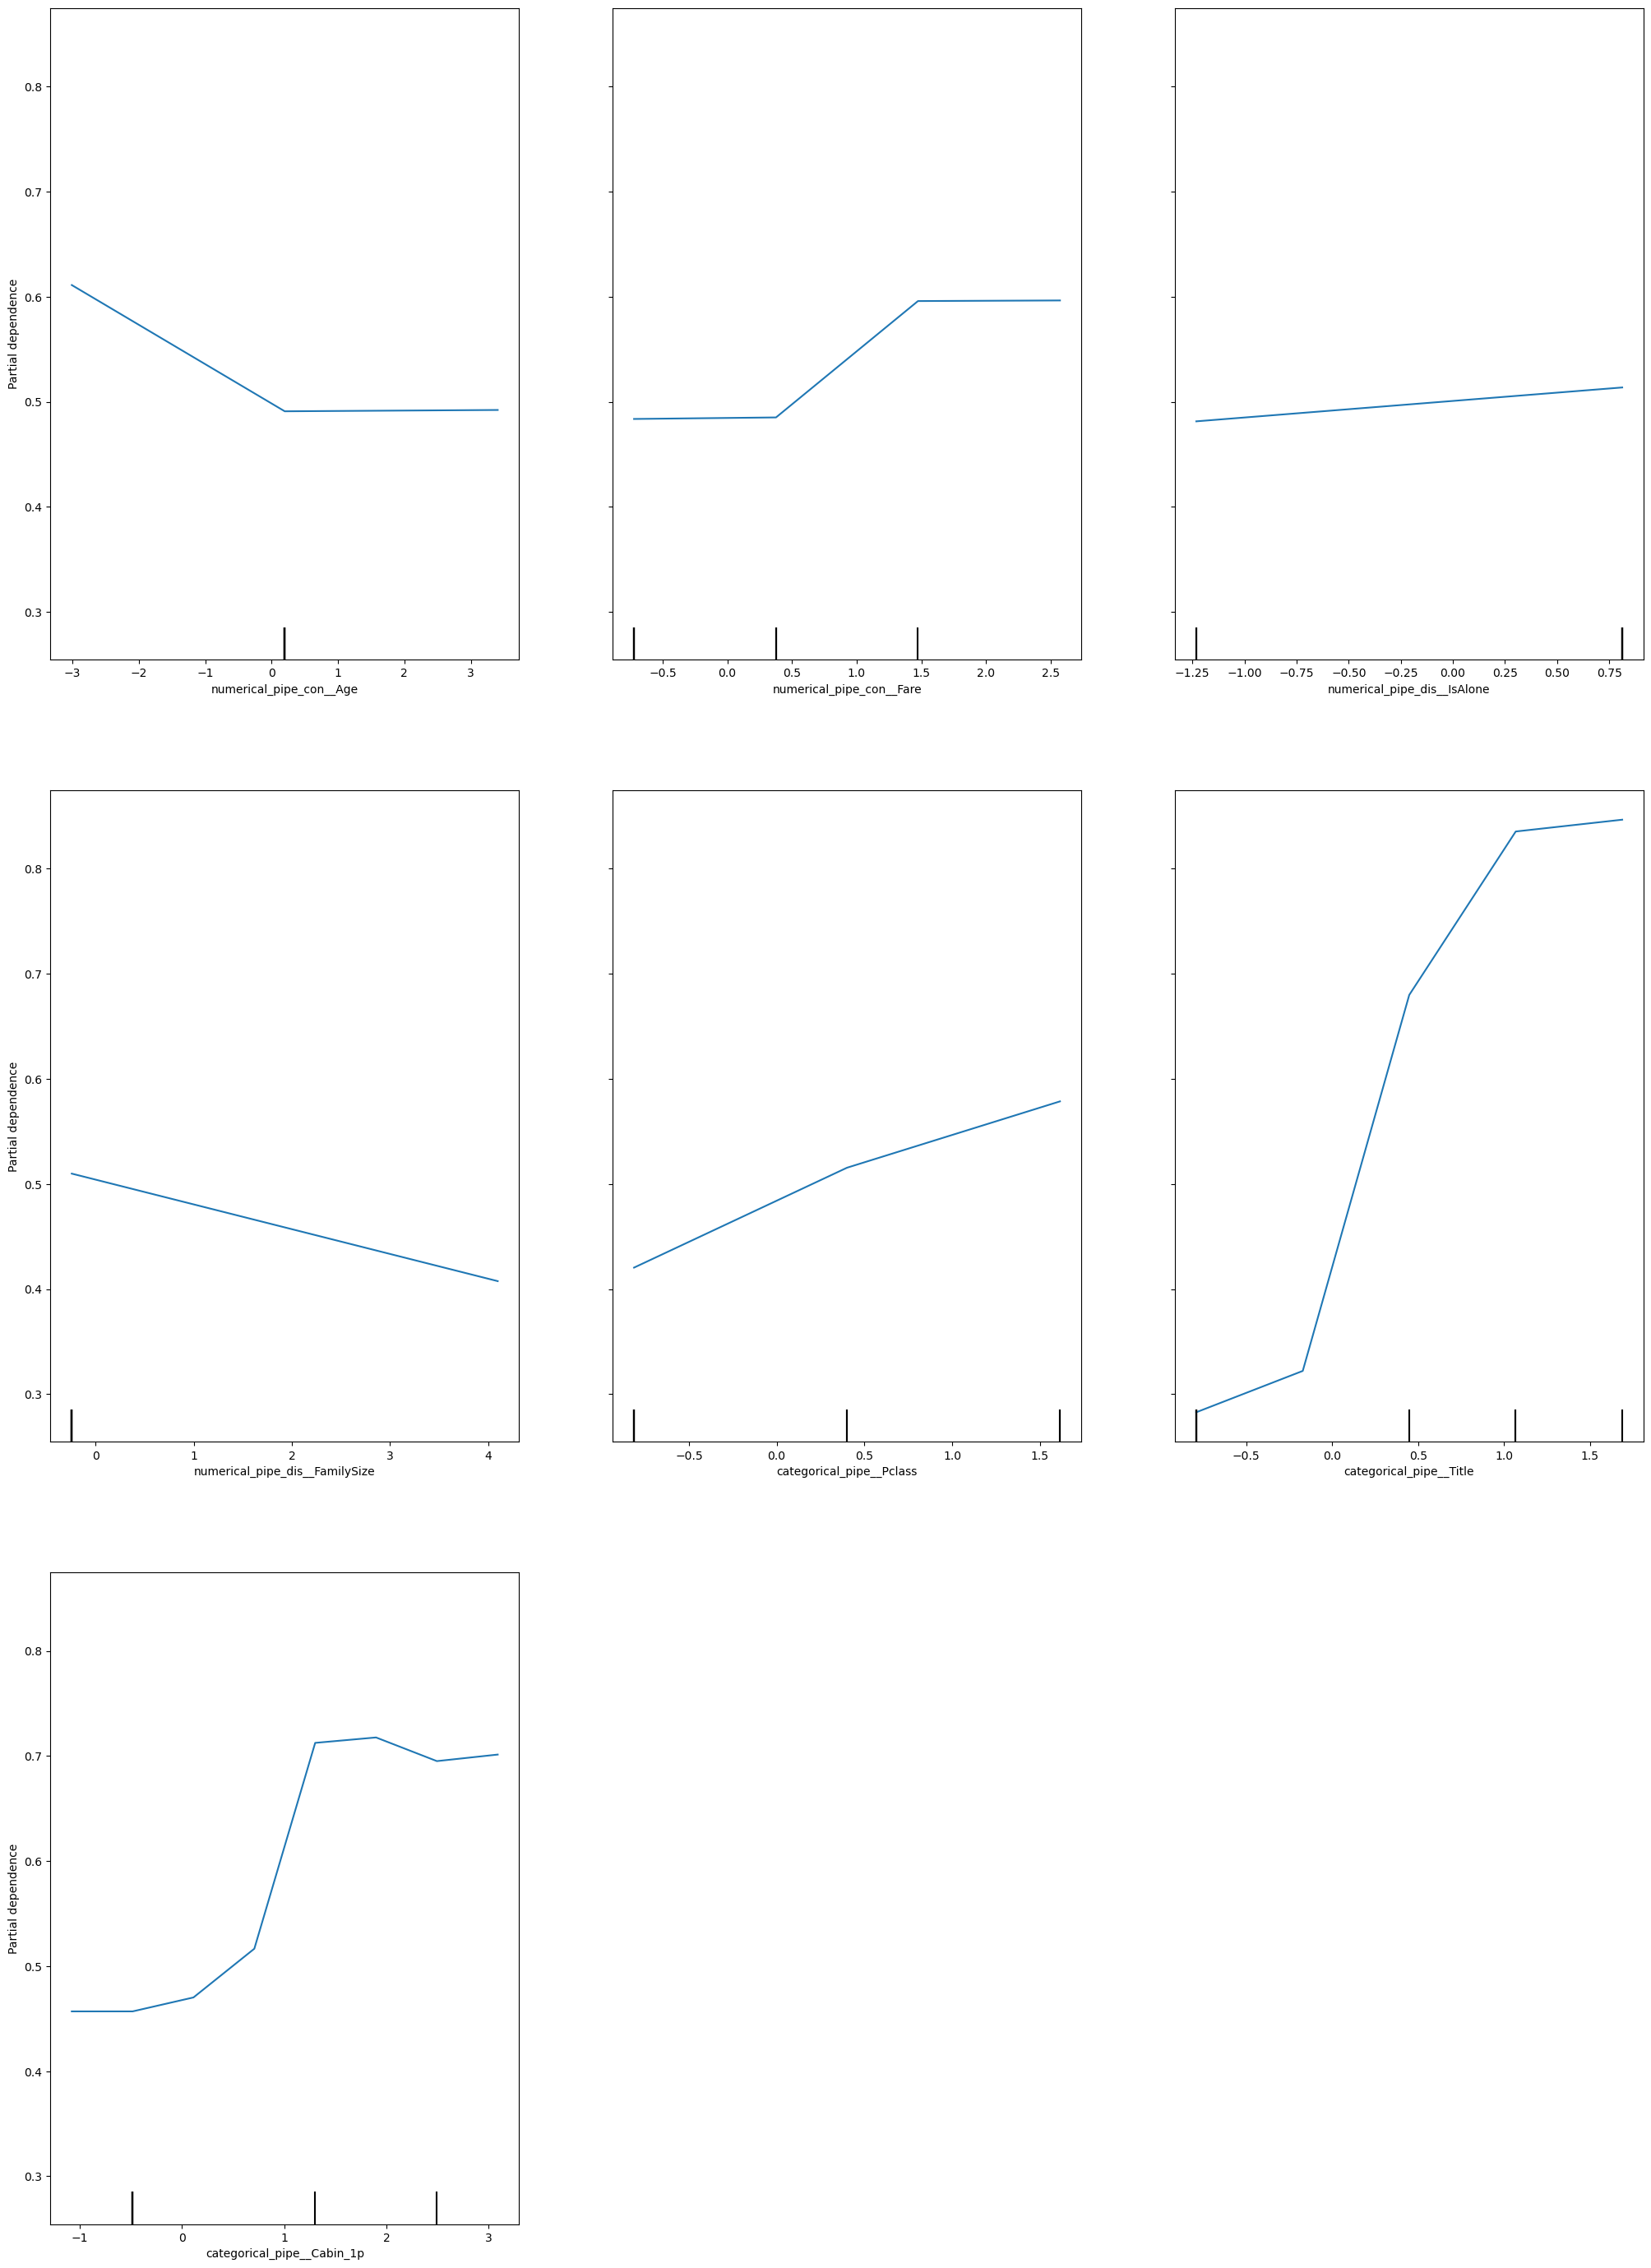

In [12]:
fig, ax = plt.subplots(figsize=(25, 35))
PartialDependenceDisplay.from_estimator(
        estimator=model,
        X=X_val,
        features = X_val.columns.tolist(),
        # categorical_features=X_val.columns[X_val.columns.str.contains('categorical_pipe')],
        random_state=23,
        ax=ax
    )

# Shap Values

In [13]:
X_val_proba = model.predict_proba(X_val)

In [14]:
explainer = shap.Explainer(model.predict_proba, X_train)

In [15]:
shap_values_train = explainer(X_train)
shap_values_val = explainer(X_val)

ExactExplainer explainer: 713it [00:34, 16.04it/s]                         


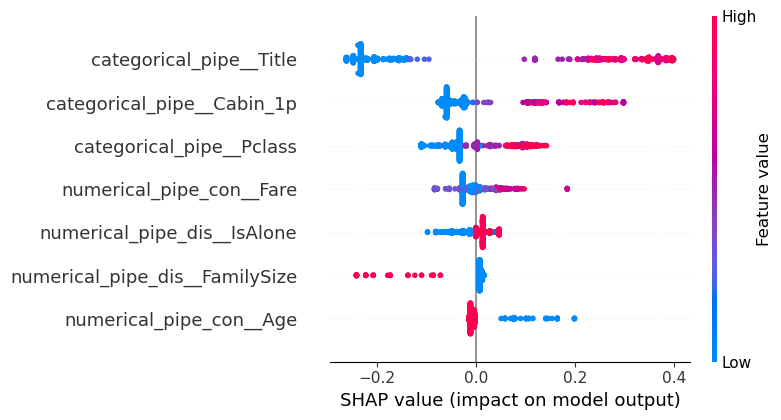

In [16]:
# Classe positiva (geralmente índice 1)
shap.summary_plot(
    shap_values_train.values[:, :, 1],
    X_train
)

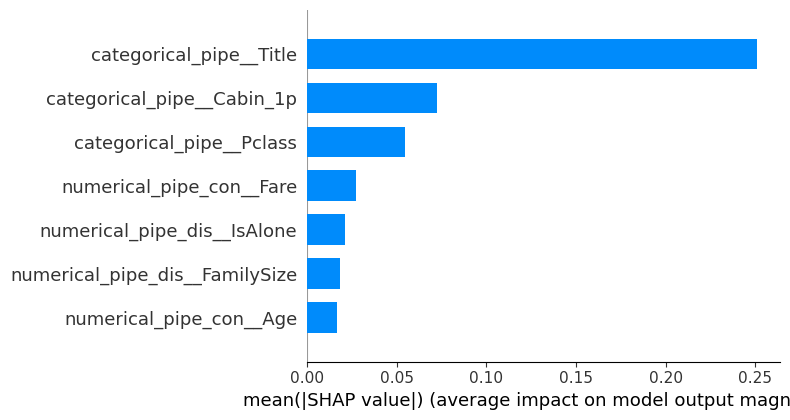

In [17]:
shap.summary_plot(
    shap_values_train.values[:, :, 1],
    X_train,
    plot_type="bar"
)


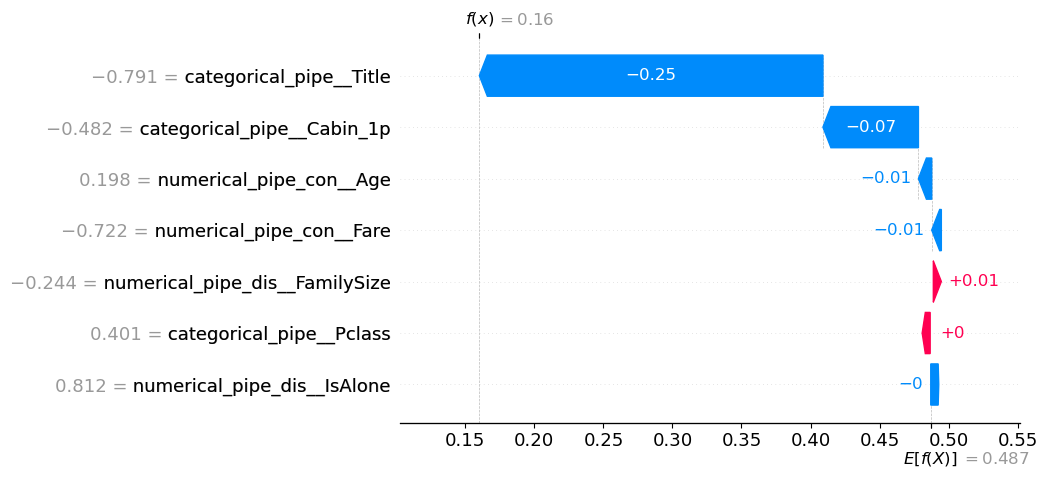

In [19]:
shap.plots.waterfall(shap_values_val[1,:,1])

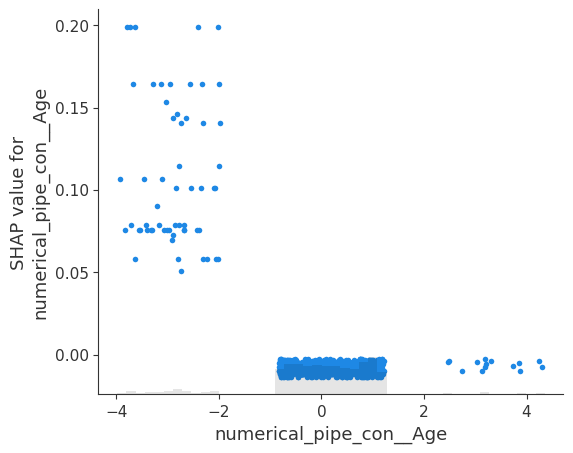

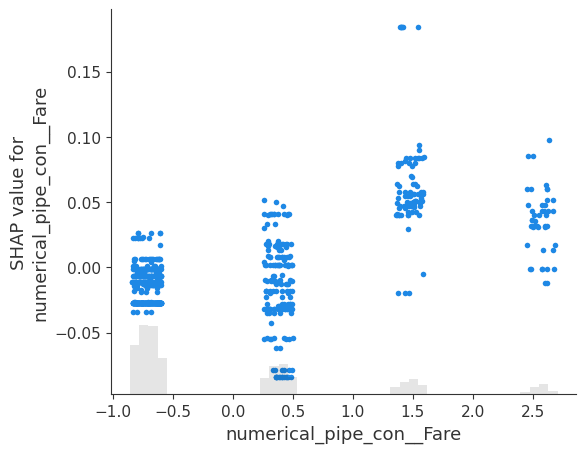

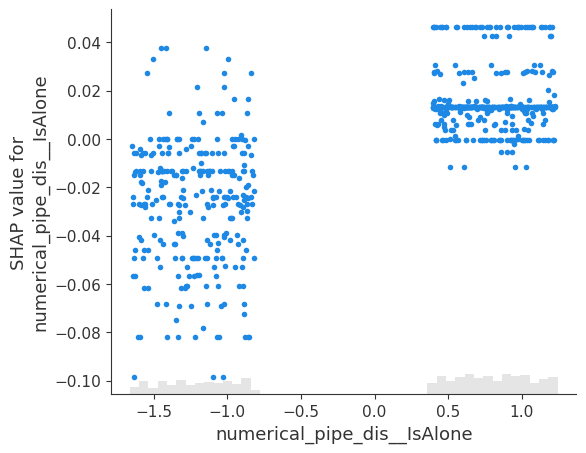

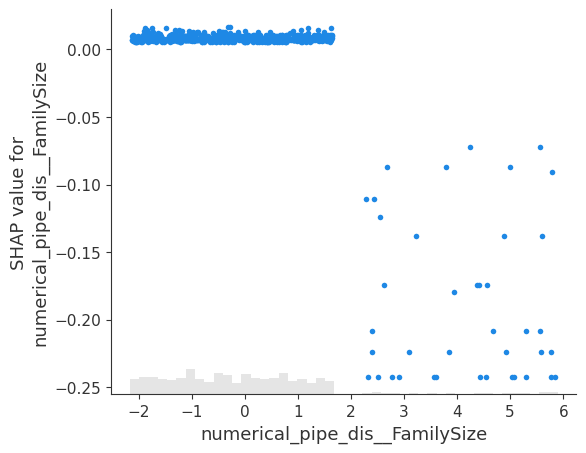

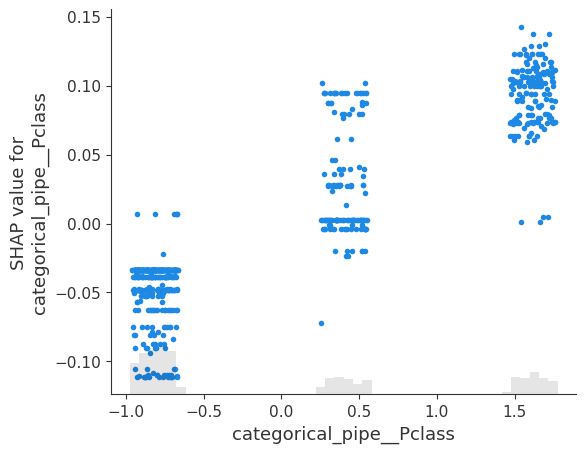

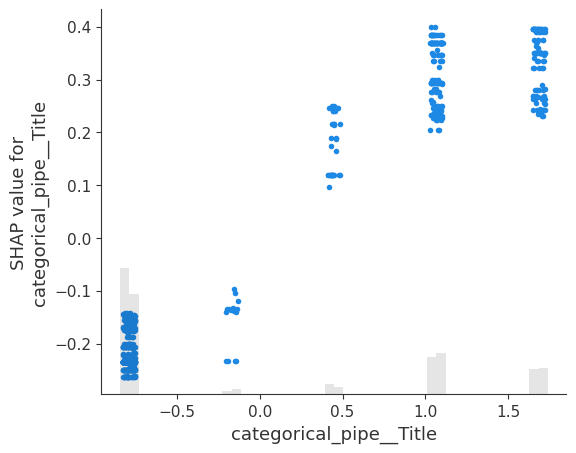

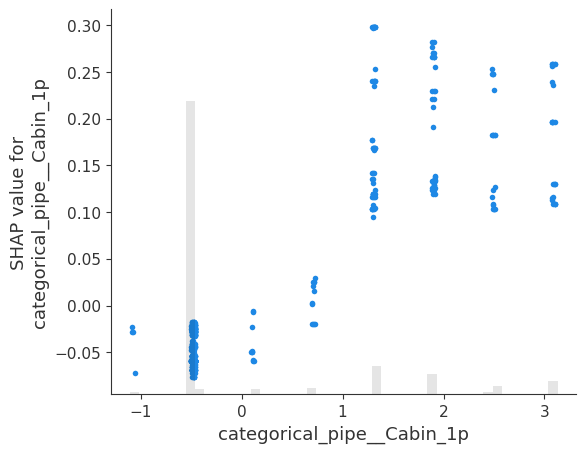

In [20]:
for col in X_val.columns:
    shap.plots.scatter(shap_values_train[:,col,1])

In [21]:
X_train['numerical_pipe_dis__FamilySize'].unique()

array([-0.24397502,  4.09878031])